Nama: Rija Aulia Mayatri                                           

NIM: 2509116011

Kelas: Sistem Informasi A'25

#**DAILY FOOD DELIVERY ORDERS AND DELIVERY TIME**

#**Import Library**

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#**Business Understanding**

**Business
Objective**

Dataset ini menggambarkan aktivitas pesanan harian pada layanan pengantaran makanan, dengan tujuan untuk memahami pola pemesanan serta proses pengiriman secara lebih realistis. Data yang tersedia mencakup informasi demografi pelanggan, jenis restoran, nilai pesanan, jarak dan durasi pengiriman, metode pembayaran, rating mitra pengantar, hingga status akhir pesanan.

Permasalahan utama yang terlihat adalah tingginya persentase pesanan yang Dibatalkan (33,6%) dan Ditunda (32,0%), sehingga hampir dua pertiga pesanan tidak berakhir dengan sukses. Kondisi ini menunjukkan adanya potensi kendala pada efisiensi operasional, ketersediaan mitra pengantar, atau ketepatan estimasi waktu pengiriman. Jika tidak ditangani, hal ini dapat berdampak pada kepuasan pelanggan dan penurunan pendapatan.

**Access Situation**

* Kondisi Dataset:

Dataset terdiri dari 2.600 baris dan 10 kolom. Setelah dilakukan pengecekan kualitas data, tidak ditemukan missing values, data duplikat, maupun outlier yang signifikan pada kolom numerik. Hal ini menunjukkan bahwa dataset sudah bersih dan dapat langsung digunakan untuk analisis tanpa proses pembersihan tambahan yang kompleks.

* Tantangan

Tantangan utama yang dihadapi bisnis adalah rendahnya efisiensi operasional, yang tercermin dari tingginya angka pembatalan dan keterlambatan pesanan. Oleh karena itu, perlu dilakukan analisis untuk mengidentifikasi faktor-faktor yang memengaruhi kondisi tersebut.

**Analytic Goals**

* Mengidentifikasi jenis restoran atau metode pembayaran yang memiliki tingkat pembatalan dan keterlambatan tertinggi.

* Menganalisis hubungan antara durasi pengiriman dan status pesanan untuk mengetahui apakah waktu tempuh yang lebih lama berkaitan dengan peningkatan keterlambatan atau pembatalan.

* Memahami distribusi dan karakteristik usia pelanggan untuk mendukung strategi pemasaran yang lebih tepat sasaran.

* Menentukan area operasional yang perlu ditingkatkan guna menekan angka pembatalan dan keterlambatan pesanan.

**Project Plan**

* Data Understanding: Memuat dataset dan meninjau informasi dasar seperti jumlah baris, kolom, tipe data, serta statistik deskriptif untuk memperoleh gambaran awal.

* Data Quality Verification: Memastikan kualitas data dengan mengecek missing values, inkonsistensi, duplikasi, dan outlier guna menjamin keandalan analisis.

* Eksplorasi Data (Exploratory Data Analysis - EDA):
  * Comparison: Membandingkan metrik utama seperti waktu pengiriman, rating mitra, dan status pesanan berdasarkan jenis restoran.
  * Composition: Menganalisis proporsi status pesanan dan metode pembayaran.
  * Distribution: Mengkaji distribusi usia pelanggan.
  * Relationship: Menguji hubungan antara metode pembayaran dan status pesanan.








#**Data Understanding**

##**Memuat Dataset**

Dataset ini berisi data tentang pesanan harian pada layanan pengantaran makanan, yang dirancang untuk mengetahui pola pemesanan dan proses pengiriman secara realistis di sebuah platform pemesanan makanan online. Data yang tersedia meliputi informasi demografi pelanggan, jenis restoran, nilai pesanan, jarak pengiriman, waktu tempuh, metode pembayaran, hingga status akhir pesanan.

In [ ]:
path = "/content/drive/MyDrive/AVD/daily_food_delivery_orders.csv"

df = pd.read_csv(path)

df

,order_id,order_date,customer_age,restaurant_type,order_value,delivery_distance_km,delivery_time_minutes,payment_method,delivery_partner_rating,order_status
0,1,2024-11-05,62,Indian,497.51,11.07,79,UPI,3.9,Cancelled
1,2,2024-08-20,35,Bakery,232.32,5.83,69,Wallet,2.7,Cancelled
2,3,2024-02-28,34,Italian,540.82,3.61,70,Wallet,3.4,Cancelled
3,4,2024-05-26,65,Cafe,1197.99,3.66,18,Card,4.6,Cancelled
4,5,2024-09-21,40,Indian,947.03,12.08,57,UPI,4.9,Delayed
...,...,...,...,...,...,...,...,...,...,...
2595,2596,2024-05-20,46,Cafe,738.51,9.12,31,Wallet,4.5,Cancelled
2596,2597,2024-05-15,56,Indian,421.78,8.29,66,Card,2.8,Delayed
2597,2598,2024-10-18,32,Cafe,1009.93,12.80,73,UPI,4.4,Delivered
2598,2599,2024-04-24,55,Bakery,240.97,13.56,56,Cash,4.3,Delivered


#**Data Description**

###**Informasi dasar**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2600 entries, 0 to 2599
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   order_id                 2600 non-null   int64  
 1   order_date               2600 non-null   object 
 2   customer_age             2600 non-null   int64  
 3   restaurant_type          2600 non-null   object 
 4   order_value              2600 non-null   float64
 5   delivery_distance_km     2600 non-null   float64
 6   delivery_time_minutes    2600 non-null   int64  
 7   payment_method           2600 non-null   object 
 8   delivery_partner_rating  2600 non-null   float64
 9   order_status             2600 non-null   object 
dtypes: float64(3), int64(3), object(4)
memory usage: 203.3+ KB


Berdasarkan data di atas, dapat diketahui bahwa dataset ini memiliki 2600 baris dan 10 kolom.

###**Informasi lanjutan**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2600 entries, 0 to 2599
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   order_id                 2600 non-null   int64  
 1   order_date               2600 non-null   object 
 2   customer_age             2600 non-null   int64  
 3   restaurant_type          2600 non-null   object 
 4   order_value              2600 non-null   float64
 5   delivery_distance_km     2600 non-null   float64
 6   delivery_time_minutes    2600 non-null   int64  
 7   payment_method           2600 non-null   object 
 8   delivery_partner_rating  2600 non-null   float64
 9   order_status             2600 non-null   object 
dtypes: float64(3), int64(3), object(4)
memory usage: 203.3+ KB


1. Order ID:
        Jumlah baris: 2600
        Tipe data: int64
        Deskripsi: ID Pesanan

2. Order Date:
        Jumlah baris: 2600
        Tipe data: object
        Deskripsi: Tanggal Pesanan

3. Customer Age:
        Jumlah baris: 2600
        Tipe data: int64
        Deskripsi: Umur Pelanggan

4. Restaurant Type:
        Jumlah baris: 2600
        Tipe data: object
        Deskripsi: Tipe Restauran

5. Order Value:
        Jumlah baris: 2600
        Tipe data: float64
        Deskripsi: Nilai Pesanan

6. Delivery Distance (KM):
        Jumlah baris: 2600
        Tipe data: float64
        Deskripsi: Jarak Pengiriman (KM)

7. Delivery Time (Minutes):
        Jumlah baris: 2600
        Tipe data: int64
        Deskripsi: Waktu Pengiriman (Menit)

8. Payment Method:
        Jumlah baris: 2600
        Tipe data: Object
        Deskripsi: Metode Pembayaran

9. Delivery Partner Rating:
        Jumlah baris: 2600
        Tipe data: float64
        Deskripsi: Rating Mitra Pengantar

10. Order Status:
        Jumlah baris: 2600
        Tipe data: Object
        Deskripsi: Status Pesanan


###**Informasi statistik deskriptif**

In [ ]:
df.describe(include='all')

,order_id,order_date,customer_age,restaurant_type,order_value,delivery_distance_km,delivery_time_minutes,payment_method,delivery_partner_rating,order_status
count,2600.000000,2600,2600.000000,2600,2600.000000,2600.000000,2600.000000,2600,2600.000000,2600
unique,NaN,366,NaN,6,NaN,NaN,NaN,4,NaN,3
top,NaN,2024-11-27,NaN,Bakery,NaN,NaN,NaN,UPI,NaN,Delivered
freq,NaN,16,NaN,454,NaN,NaN,NaN,660,NaN,895
mean,1300.500000,NaN,41.492308,NaN,670.293873,7.886800,51.748462,NaN,3.749577,NaN
std,750.699674,NaN,13.977196,NaN,300.767326,4.211332,21.987540,NaN,0.721153,NaN
min,1.000000,NaN,18.000000,NaN,150.900000,0.500000,15.000000,NaN,2.500000,NaN
25%,650.750000,NaN,29.000000,NaN,406.402500,4.207500,32.000000,NaN,3.100000,NaN
50%,1300.500000,NaN,41.000000,NaN,667.580000,7.965000,51.000000,NaN,3.800000,NaN
75%,1950.250000,NaN,54.000000,NaN,927.480000,11.590000,70.000000,NaN,4.400000,NaN


1. Count (Kelengkapan Data)
Berdasarkan data, total baris transaksi adalah 2600. Maka dapat disimpulkan:
* Tidak ada kolom yang menghilang

Kesimpulan: Tidak ada kolom yang mengalami missing values, maka dari itu kolom sudah lengkap.



---


2. Mean vs Median (Distribusi Data)

* Kolom Order ID
  * Mean = 1300.500000
  * Median = 1300.500000
  - Nilai rata-rata sama persis dengan median

Hal ini menunjukkan bahwa distribusi data Order ID benar-benar simetris dan tidak terdapat outlier yang memengaruhi nilai rata-rata.

* Kolom Customer Age
 * Mean = 41.492308
 * Median = 41.000000
 - Nilai rata-rata sedikit lebih besar dari median

 Hal ini menunjukkan bahwa distribusi usia pelanggan relatif mendekati simetris, namun terdapat sedikit kecenderungan miring ke kanan.

* Kolom Order Value
  * Mean = 670.293873
  * Median = 667.580000
  - Nilai rata-rata sedikit lebih besar dari median.
  
Hal ini menunjukkan bahwa distribusi Order Value relatif mendekati simetris, namun terdapat sedikit kecenderungan miring ke kanan.


* Kolom Delivery Distance KM
  * Mean = 7.886800
  * Median = 7.965000
  - Nilai rata-rata sedikit lebih kecil dari median

Hal ini menunjukkan bahwa distribusi Delivery Distance relatif mendekati simetris, namun terdapat sedikit kecenderungan miring ke kiri.

* Kolom Delivery Time Minutes
  * Mean = 51.748462
  * Median = 51.000000
  - Nilai rata-rata sedikit lebih besar dari median

Hal ini menunjukkan bahwa distribusi Delivery Time relatif mendekati simetris, namun terdapat sedikit kecenderungan miring ke kanan.

* Kolom Delivery Partner Rating
  * Mean = 3.749577
  * Median = 3.800000
  - Nilai rata-rata sedikit lebih kecil dari median

Hal ini menunjukkan bahwa distribusi Delivery Partner Rating relatif mendekati simetris, namun terdapat sedikit kecenderungan miring ke kiri.

#####Kesimpulan: Secara umum, data pada semua variabel cukup seimbang dan tidak ada perbedaan besar antara rata-rata (mean) dan nilai tengah (median). Untuk Order ID, mean sama dengan median, artinya datanya merata tanpa angka yang ekstrem. Beberapa variabel seperti Customer Age, Order Value, dan Delivery Time sedikit miring ke kanan karena ada nilai yang lebih tinggi, sedangkan Delivery Distance dan Delivery Partner Rating sedikit miring ke kiri karena ada nilai yang lebih rendah. Secara keseluruhan, data stabil dan cocok digunakan untuk analisis lebih lanjut.
---



3. Min dan Max (Validasi Logika)

* Order ID
  * Min = 1.000000
  * Max = 2600.000000

* Customer Age
  * Min = 18.000000
  * Max = 65.000000

* Order Value
  * Min = 150.900000
  * Max = 1199.780000

* Delivery Distance KM
  * Min = 0.500000
  * Max = 14.990000

* Delivery Time Minutes
  * Min = 15.000000
  * Max = 90.000000

* Delivery Partner Rating
  * Min = 2.500000
  * Max = 5.000000

Kesimpulan:
Berdasarkan nilai minimum dan maksimum, semua data berada dalam rentang yang logis dan masuk akal. Order ID mulai dari 1 hingga 2600, menunjukkan semua transaksi tercatat dengan benar. Usia pelanggan berkisar antara 18 hingga 65 tahun, sesuai dengan rentang usia dewasa. Order Value berada di antara 150,90 hingga 1.199,78, sedangkan jarak pengiriman antara 0,5 km sampai 14,99 km, dan waktu pengiriman antara 15 hingga 90 menit. Rating mitra pengiriman juga berada pada skala yang wajar, yaitu 2,5 hingga 5. Secara keseluruhan, data tervalidasi dengan baik dan tidak ada nilai yang aneh atau tidak masuk akal.



---



4. Standar Deviasi (std) - Variabilitas Data

* Order ID
  * Mean = 1300.500000
  * Std = 750.699674

* Customer Age
  * Mean = 41.492308
  * Std = 13.977196

* Order Value
  * Mean = 670.293873
  * Std = 300.767326

* Delivery Distance KM
  * Mean = 7.886800
  * Std = 4.211332

* Delivery Time Minutes
  * Mean = 51.748462
  * Std = 21.987540

* Delivery Partner Rating
  * Mean = 3.749577
  * Std = 0.721153

Kesimpulan:

Berdasarkan standar deviasi, variasi atau sebaran data berbeda-beda untuk setiap variabel. Order ID memiliki sebaran besar karena mencakup banyak transaksi, sedangkan Customer Age relatif lebih stabil dengan variasi sekitar 14 tahun. Order Value menunjukkan variasi sedang, artinya nilai pesanan bervariasi tetapi tidak ekstrem. Delivery Distance dan Delivery Time memiliki sebaran yang cukup, mencerminkan bahwa jarak dan waktu pengiriman bervariasi di antara pengiriman yang berbeda. Sedangkan Delivery Partner Rating memiliki standar deviasi kecil, menunjukkan bahwa hampir semua rating mendekati nilai rata-rata dan konsisten. Secara keseluruhan, data menunjukkan variasi yang wajar sesuai karakteristik masing-masing variabel.

#**Verify Data Quality**

###**Mengecek tipe data**

Pada bagian ini kita akan mengecek tipe data di setiap kolom terlebih dahulu agar bisa melacak data yang sekiranya bisa kita ketahui mengandung data yang unik.

Dikarnakan ada keanehan tipe data di bagian order date maka kita harus mengecek apakah ada data yang 'unik'.

In [ ]:
df.dtypes

,0
order_id,int64
order_date,object
customer_age,int64
restaurant_type,object
order_value,float64
delivery_distance_km,float64
delivery_time_minutes,int64
payment_method,object
delivery_partner_rating,float64
order_status,object


###**Inconsistent values**

Pada tahap ini, kita perlu mengecek kekonsistenan data, contoh nya dalam penulisan. Hal ini dilakukan agar data tidak terduplikat dengan baris yang sebenarnya sama akan tetapi bisa terduplikat karena tidak konsisten.

**1. Order Date**

Pada kolom ini, dapat terlihat format tanggal konsisten. Maka dari itu untuk memastikan kolom order_date dapat digunakan untuk operasi berbasis tanggal, kita perlu mengubah tipe datanya dari object menjadi datetime.

In [ ]:
print(df['order_date'].unique())

['2024-11-05' '2024-08-20' '2024-02-28' '2024-05-26' '2024-09-21'
 '2024-03-16' '2024-11-20' '2024-11-24' '2024-07-23' '2024-07-01'
 '2024-09-16' '2024-08-27' '2024-01-09' '2024-09-02' '2024-08-21'
 '2024-07-24' '2024-04-09' '2024-04-20' '2024-03-01' '2024-08-23'
 '2024-10-22' '2024-12-24' '2024-07-11' '2024-06-12' '2024-03-18'
 '2024-06-28' '2024-03-25' '2024-09-20' '2024-08-04' '2024-08-13'
 '2024-08-15' '2024-04-24' '2024-03-28' '2024-10-10' '2024-03-31'
 '2024-01-14' '2024-12-08' '2024-02-22' '2024-12-12' '2024-10-24'
 '2024-05-30' '2024-11-23' '2024-03-02' '2024-11-02' '2024-11-28'
 '2024-09-01' '2024-01-29' '2024-02-07' '2024-11-11' '2024-08-28'
 '2024-10-03' '2024-03-11' '2024-12-19' '2024-12-20' '2024-07-28'
 '2024-03-08' '2024-05-09' '2024-12-09' '2024-10-20' '2024-09-11'
 '2024-10-14' '2024-05-01' '2024-06-11' '2024-10-11' '2024-05-25'
 '2024-06-24' '2024-08-12' '2024-12-13' '2024-07-16' '2024-08-26'
 '2024-11-06' '2024-08-31' '2024-09-12' '2024-07-05' '2024-06-03'
 '2024-09-

###**Missing values**

In [ ]:
pd.DataFrame(df.isna().sum() / len(df) * 100, columns=['Null Ratio in %'])

,Null Ratio in %
order_id,0.0
order_date,0.0
customer_age,0.0
restaurant_type,0.0
order_value,0.0
delivery_distance_km,0.0
delivery_time_minutes,0.0
payment_method,0.0
delivery_partner_rating,0.0
order_status,0.0


Terlihat bahwa di dalam data ini tidak terdapat missing values. Maka dari itu tidak perlu adanya penindak lanjutan.

###**Duplicated values**

Pada tahap ini, kita akan mengecek duplikasi pada dataset. Hal ini dilakukan agar dataset memiliki insight dan hasil yang bersih.

In [ ]:
df[df.duplicated()]

,order_id,order_date,customer_age,restaurant_type,order_value,delivery_distance_km,delivery_time_minutes,payment_method,delivery_partner_rating,order_status


Terlihat pada dataset ini tidak ada duplikasi. Maka hal ini tidak perlu ditangani.

###**Outliers values**

Di dalam data ini tidak ditemukan adanya  nilai ekstrem (outliers) pada kolom yang bertipe data kan numerik. Maka dari itu tidak perlu adanya penindak lanjutan.

In [ ]:
results = []

cols = df.select_dtypes(include=['float64', 'int64'])

for col in cols:
  q1 = df[col].quantile(0.25)
  q3 = df[col].quantile(0.75)
  iqr = q3 - q1
  lower_bound = q1 - 1.5*iqr
  upper_bound = q3 + 1.5*iqr
  outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
  percent_outliers = (len(outliers)/len(df))*100
  results.append({'Kolom': col, 'Persentase Outliers': percent_outliers})

# Dataframe dari list hasil
results_df = pd.DataFrame(results)
results_df.set_index('Kolom', inplace=True)
results_df = results_df.rename_axis(None, axis=0).rename_axis('Kolom', axis=1)

# Tampilkan dataframe
display(results_df)

Kolom,Persentase Outliers
order_id,0.0
customer_age,0.0
order_value,0.0
delivery_distance_km,0.0
delivery_time_minutes,0.0
delivery_partner_rating,0.0


#**Data Exploration (EDA)**

##**Comparison (Perbandingan)**

Pada bagian ini, kita akan membandingkan beberapa  hal termasuk waktu pengiriman, rating mitra pengiriman, dan status pesanan pada setiap tipe restoran. Dengan tujuan agar bisa mengetahui kualitas dari setiap tipe restoran berdasarkan ketiga hal tersebut.

Visualisasi: Bar Chart (Visualisasi batang)

###**Perbandingan waktu pengiriman di tiap restoran**

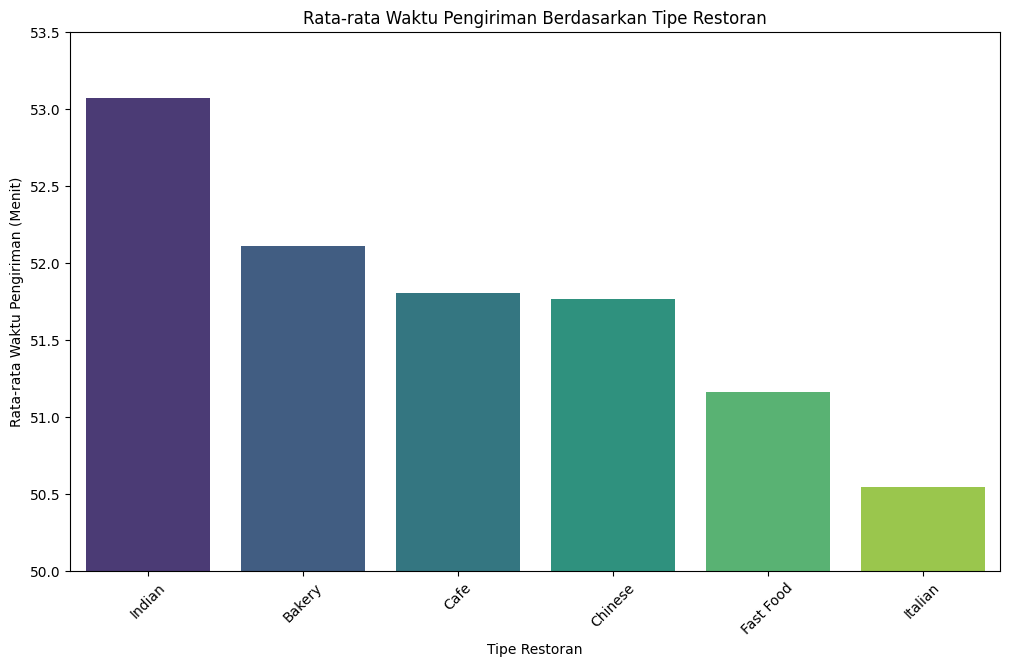

In [ ]:
average_delivery_time_by_restaurant = df.groupby('restaurant_type')['delivery_time_minutes'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 7))
sns.barplot(x=average_delivery_time_by_restaurant.index, y=average_delivery_time_by_restaurant.values, palette='viridis', hue=average_delivery_time_by_restaurant.index, legend=False)
plt.title('Rata-rata Waktu Pengiriman Berdasarkan Tipe Restoran')
plt.xlabel('Tipe Restoran')
plt.ylabel('Rata-rata Waktu Pengiriman (Menit)')
plt.xticks(rotation=45)
plt.ylim(50, 53.5)
plt.show()

Pada bagian ini kita dapat melihat bahwa tipe restoran indian lebih lama waktu pengirimannya dibandingkan dengan restoran italian, jadi kita dapat menyimpulkan bahwa kemungkinan perbedaan tersebut karna jauhnya jarak restoran dengan titik sampainya pesanan.

###**Perbandingan rating mitra pengiriman di tiap restoran**

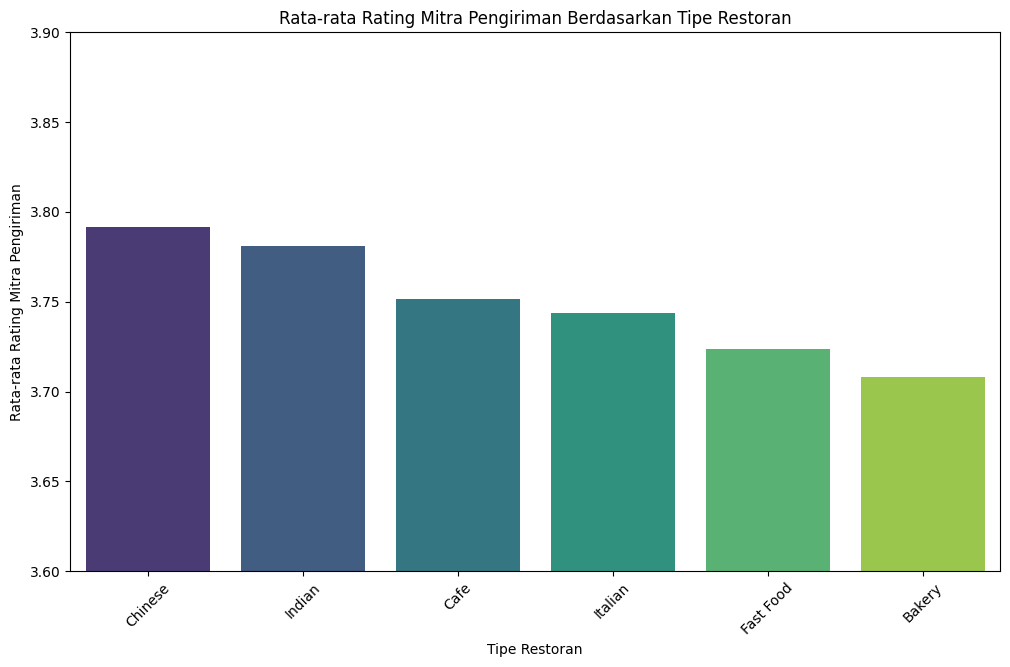

In [ ]:
average_delivery_partner_rating_by_restaurant = df.groupby('restaurant_type')['delivery_partner_rating'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 7))
sns.barplot(x=average_delivery_partner_rating_by_restaurant.index, y=average_delivery_partner_rating_by_restaurant.values, palette='viridis', hue=average_delivery_partner_rating_by_restaurant.index, legend=False)
plt.title('Rata-rata Rating Mitra Pengiriman Berdasarkan Tipe Restoran')
plt.xlabel('Tipe Restoran')
plt.ylabel('Rata-rata Rating Mitra Pengiriman')
plt.xticks(rotation=45)
plt.ylim(3.6, 3.9)
plt.show()

Dari visualisasi ini, kita dapat melihat bahwa rating mitra paling tinggi yaitu dari restorang chinese sedangkan rating yang paling rendah adalah bakery yang dapat disimpulkan bahwa adanya kemungkinan hal tersebut dikarnakan kesalahan mitra pengiriman itu sendiri, maka dari itu restoran bakery harus mengevaluasi terkait hal tersebut.

<Figure size 1200x700 with 0 Axes>

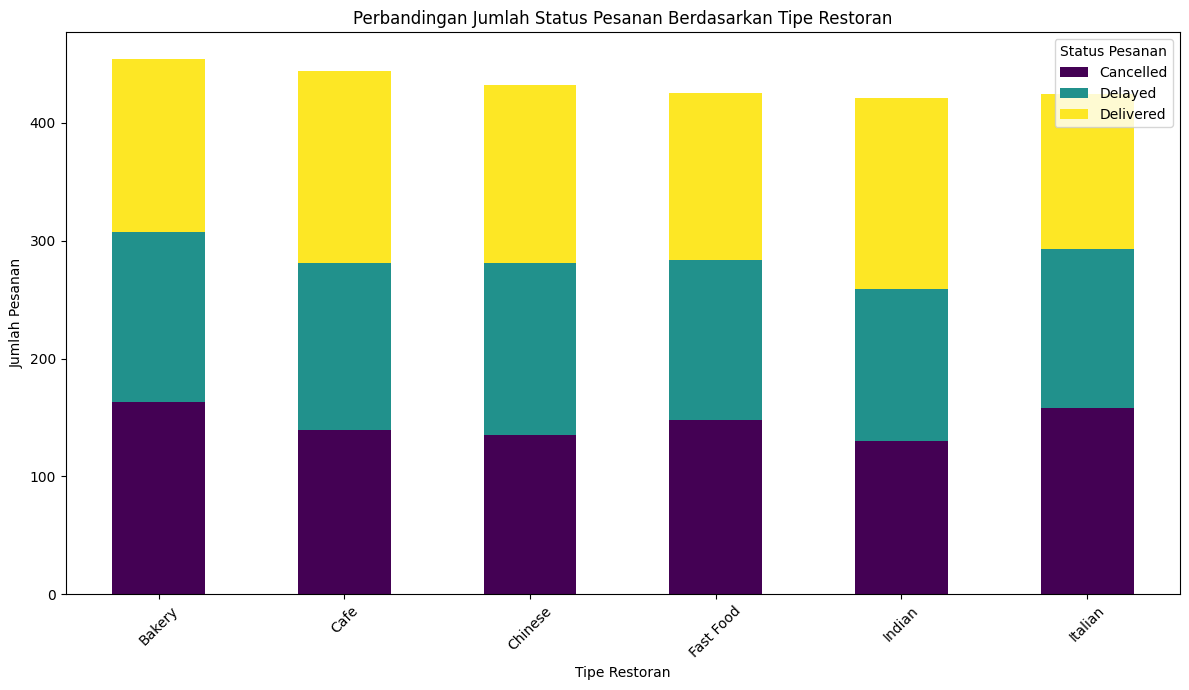

In [ ]:
order_status_by_restaurant = df.groupby(['restaurant_type', 'order_status']).size().unstack(fill_value=0)

plt.figure(figsize=(12, 7))
order_status_by_restaurant.plot(kind='bar', stacked=True, colormap='viridis', figsize=(12, 7))
plt.title('Perbandingan Jumlah Status Pesanan Berdasarkan Tipe Restoran')
plt.xlabel('Tipe Restoran')
plt.ylabel('Jumlah Pesanan')
plt.xticks(rotation=45)
plt.legend(title='Status Pesanan')
plt.tight_layout()
plt.show()

Melalui visualisasi ini, kita dapat mengetahui status pesanan yang paling banyak mengalami pembatalan dan penundaan yaitu restoran bakery dengan restoran italian, yang dapat disimpulkan adanya permasalahan internal itu sendiri maupun dengan mitra pesanan.

**Kesimpulan:**

Dari ketiga visualisasi tersebut, kita dapat mengetahui yang mana saja restoran yang perlu evaluasi secara mendalam, baik dari segi internal maupun eksternal. Di sini kita dapat mengetahui bahwa restoran bakery maupun italian memerlukan hal tersebut, hal ini bisa menjadi pembelajaran untuk selanjutnya jika ingin membuka restoran baru.

##**Composition (Komposisi)**

Pada bagian ini kita akan menganalisis presentase status pesanan, dan metode pembayaran.
Tujuan dari analisis ini agar kita bisa mengetahui status pesanan yang paling mendominasi juga metode pembayaran yang paling banyak digunakan oleh pembeli.

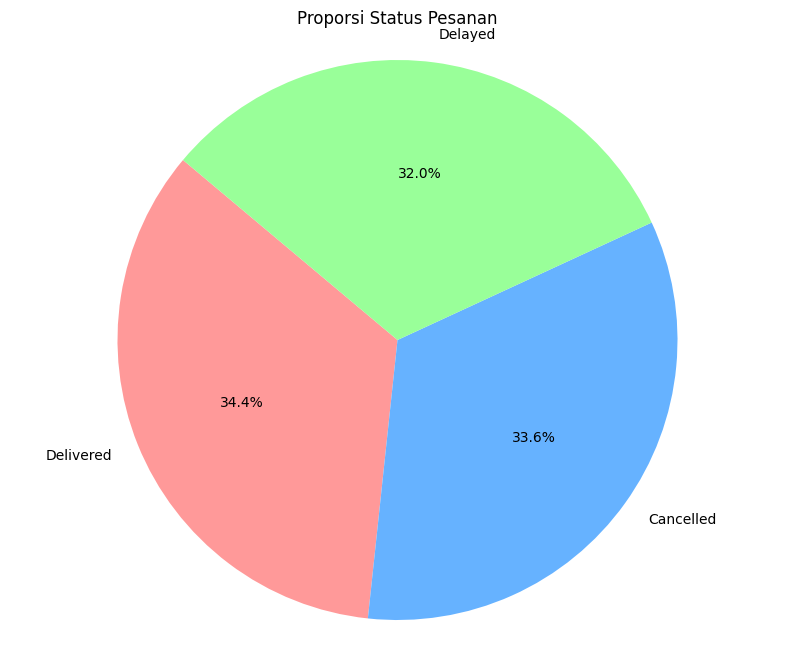

In [ ]:
order_status_composition = df['order_status'].value_counts(normalize=True) * 100

plt.figure(figsize=(10, 8))
order_status_composition.plot(kind='pie', autopct='%1.1f%%', startangle=140, colors=['#FF9999', '#66B2FF', '#99FF99'])
plt.title('Proporsi Status Pesanan')
plt.ylabel('')
plt.axis('equal')
plt.show()

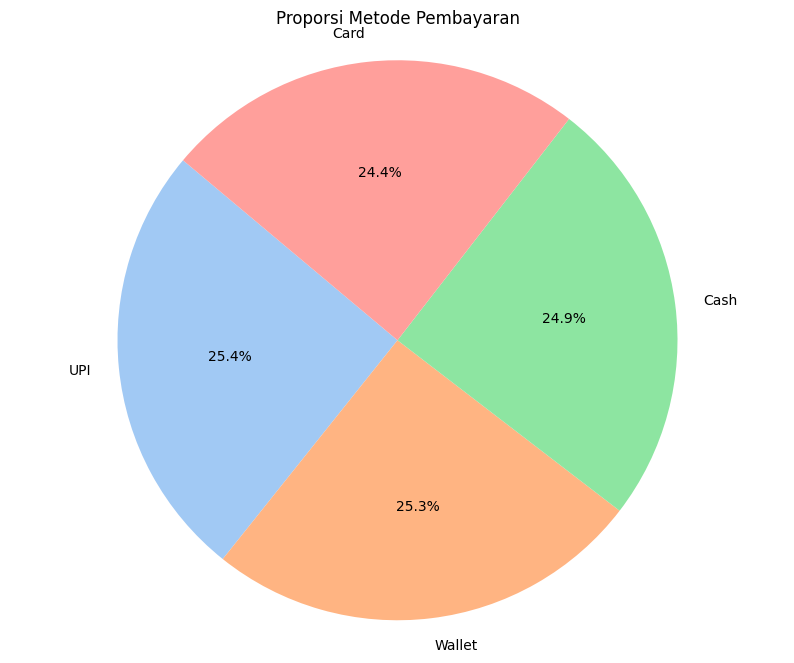

In [ ]:
payment_method_composition = df['payment_method'].value_counts(normalize=True) * 100

plt.figure(figsize=(10, 8))
payment_method_composition.plot(kind='pie', autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
plt.title('Proporsi Metode Pembayaran')
plt.ylabel('')
plt.axis('equal')
plt.show()

**Kesimpulan:**

Berdasarkan analisis dari visualisasi komposisi di atas, performa operasional layanan pengiriman masih belum optimal karena hanya 34,4% pesanan yang berhasil delivered, sementara 32% mengalami keterlambatan dan 33,6% dibatalkan, sehingga hampir dua pertiga pesanan tidak selesai dengan baik. Tingginya proporsi delayed dan canceled mengindikasikan adanya potensi masalah pada efisiensi pengiriman, ketersediaan mitra, atau estimasi waktu yang kurang akurat, yang dapat berdampak pada kepuasan pelanggan dan penurunan pendapatan. Di sisi lain, distribusi metode pembayaran relatif seimbang (sekitar 24–25% masing-masing), dengan transaksi cashless (wallet dan UPI) sedikit lebih dominan, menunjukkan bahwa sistem pembayaran sudah berjalan baik dan bukan menjadi sumber utama permasalahan. Dengan demikian, fokus perbaikan sebaiknya diarahkan pada peningkatan kualitas operasional pengiriman untuk menekan tingkat keterlambatan dan pembatalan pesanan.


##**Distribution (Distribusi)**

Pada bagian ini, kita akan menganalisis persebaran umur para pembeli di tiap restoran dengan tujuan mengetahui preferensi setiap pembeli di berbagai umur.

Visualisasi: Histogram

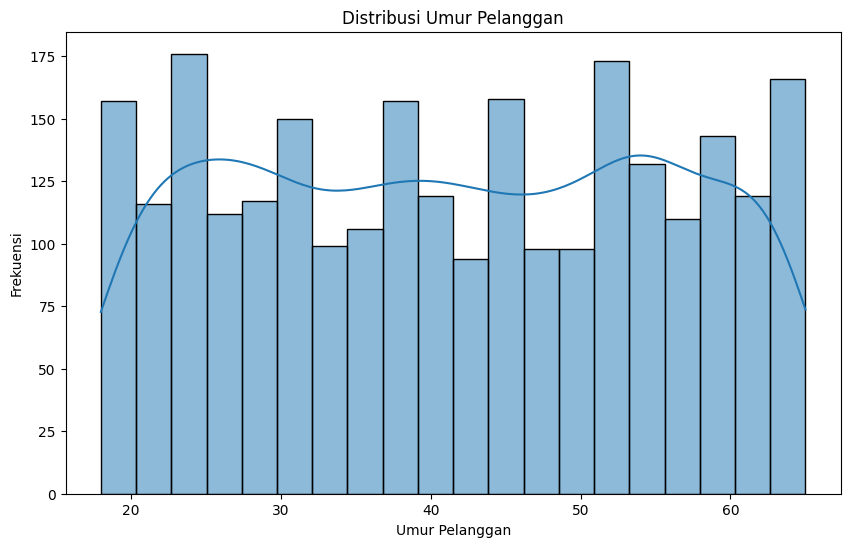

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df['customer_age'], bins=20, kde=True)
plt.title('Distribusi Umur Pelanggan')
plt.xlabel('Umur Pelanggan')
plt.ylabel('Frekuensi')
plt.show()

**Kesimpulan:**

Sebagian besar pengguna layanan pengantaran makanan ini berada pada rentang usia dewasa produktif, yaitu sekitar akhir 20-an hingga awal 50-an. Kelompok usia 18–25 tahun dan di atas 60 tahun tetap ada, tetapi jumlahnya tidak sebanyak kelompok usia menengah tersebut. Hal ini menunjukkan bahwa strategi pemasaran dan penawaran layanan sebaiknya lebih difokuskan pada segmen usia utama ini, tanpa mengabaikan kebutuhan dan preferensi dari kelompok usia lainnya agar tetap dapat menjangkau pasar yang lebih luas.


##**Relationship (Hubungan)**

Pada bagian ini, kita akan  menganalisis korelasi antara metode pembayaran dengan status pesanan.

Visualisasi: Heatmap

Tapi sebelum itu, pertama-tama kita ingin menghitung berapa banyak kemunculan setiap kombinasi dari metode pembayaran dan status pesanan terlebih dahulu dalam bentuk sebuah tabel.

In [ ]:
payment_status_crosstab = pd.crosstab(df['payment_method'], df['order_status'])
payment_status_crosstab

order_status,Cancelled,Delayed,Delivered
payment_method,,,
Card,212,189,233
Cash,218,222,208
UPI,204,227,229
Wallet,239,194,225


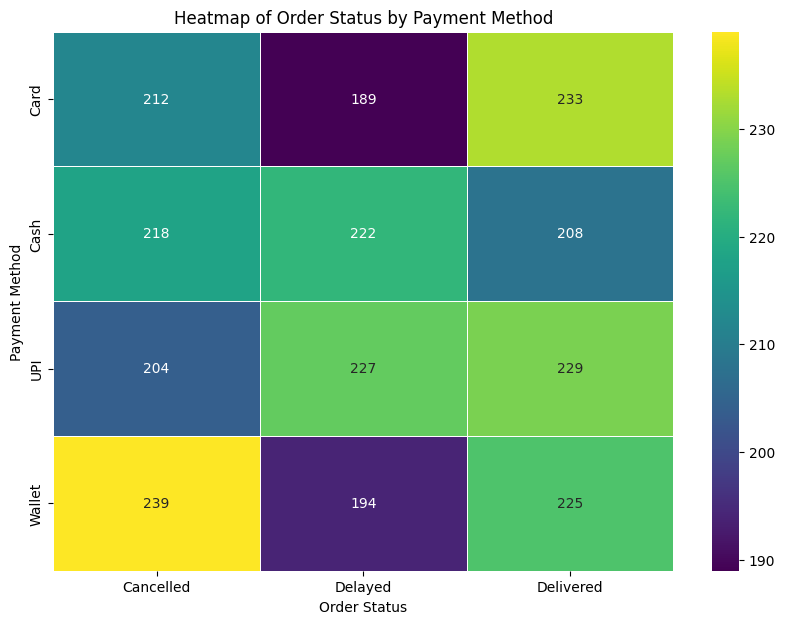

In [ ]:
plt.figure(figsize=(10, 7))
sns.heatmap(payment_status_crosstab, annot=True, fmt='d', cmap='viridis', linewidths=.5)
plt.title('Heatmap of Order Status by Payment Method')
plt.xlabel('Order Status')
plt.ylabel('Payment Method')
plt.show()

## Kesimpulan:

### Q&A
*   **Apakah metode pembayaran tertentu berkaitan dengan tingginya status Cancelled atau Delayed?**
    *   Metode pembayaran Wallet memiliki jumlah pesanan Cancelled paling tinggi, yaitu sebanyak 239 pesanan.
    *   Sementara itu, UPI memiliki jumlah pesanan Delayed yang cukup tinggi (229), dan angkanya hampir sama dengan Cash (227) serta Card (189).

*   **Apakah ada pola signifikan antara status pesanan dan metode pembayaran yang digunakan?**
    *   Terlihat bahwa Wallet cenderung memiliki tingkat pembatalan yang lebih tinggi dibandingkan metode pembayaran lainnya.
    *   Sebaliknya, Card memiliki jumlah pesanan Delivered paling banyak (233), yang menunjukkan kemungkinan bahwa metode ini lebih sering berakhir dengan pengiriman yang berhasil.

### Temuan Utama Analisis Data
*   Hasil cross-tabulation menunjukkan jumlah pesanan dengan status Cancelled, Delayed, dan Delivered untuk masing-masing metode pembayaran.
*   'Wallet memiliki jumlah pembatalan tertinggi (239).
*   Card memiliki jumlah pesanan terkirim paling banyak (233).
*   UPI dan Cash menunjukkan jumlah keterlambatan yang hampir sama, masing-masing 229 dan 227.

Visualisasi heatmap membantu memperjelas pola ini, sehingga hubungan antara metode pembayaran dan status pesanan dapat terlihat dengan lebih jelas.

### Insight dan Langkah Selanjutnya
*   Perlu dilakukan analisis lebih lanjut untuk mengetahui penyebab tingginya pembatalan pada metode Wallet, misalnya dengan mengevaluasi sistem pembayaran, pengalaman pengguna, atau karakteristik pelanggan tertentu.
*   Selain itu, menarik untuk ditelusuri apakah ada hubungan antara kecepatan atau keberhasilan pengiriman dengan metode pembayaran Card, yang mungkin dipengaruhi oleh proses transaksi yang lebih lancar atau profil pelanggan tertentu.

#**Data Preparation**

Pada bagian verifikasi kualitas data di atas, tidak ditemukan adanya banyak data yang harus ditangani, kecuali pada bagian tipe data. Maka dari itu pada bagian verifikasi data saya hanya akan memberikan contoh kode yang harus dipakai jika ingin menangani data yang bermasalah.

##**Tipe Data**

Pada bagian ini, saat melakukan verifikasi kualitas data, tidak banyak data yang harus kita tangani pada bagian tipe data. Namun terdapat data pada bagian kolom order date yang memiliki tipe data berupa object. Yang di mana seharusnya data tersebut bertipe datetime. Maka dari itu, tipe data pada bagian kolom order date akan kita ubah ke dalam tipe datetime.

In [ ]:
df.dtypes

,0
order_id,int64
order_date,object
customer_age,int64
restaurant_type,object
order_value,float64
delivery_distance_km,float64
delivery_time_minutes,int64
payment_method,object
delivery_partner_rating,float64
order_status,object


Bisa dilihat lagi bahwa tipe data yang dimiliki oleh kolom order date adalah object, yang maka dari itu kita akan mengubah tipe datanya menjadi datetime.

In [ ]:
df['order_date'] = pd.to_datetime(df['order_date'])

In [ ]:
df.dtypes

,0
order_id,int64
order_date,datetime64[ns]
customer_age,int64
restaurant_type,object
order_value,float64
delivery_distance_km,float64
delivery_time_minutes,int64
payment_method,object
delivery_partner_rating,float64
order_status,object


Dapat dilihat bahwa tipe data dari kolom order date telah berhasil kita ubah menjadi datetime.

##**Inconsistent Values**

Pada bagian ini, kita akan menangani dataset pada baris di seluruh kolom yang memiliki isi yang tidak konsisten. Namun, pertama-tama kita akan mengecek apakah terdapat dataset yang 'unik' terlebih dahulu.

In [ ]:
print(df['order_id'].unique())

[   1    2    3 ... 2598 2599 2600]


In [ ]:
print(df['order_date'].unique())

<DatetimeArray>
['2024-11-05 00:00:00', '2024-08-20 00:00:00', '2024-02-28 00:00:00',
 '2024-05-26 00:00:00', '2024-09-21 00:00:00', '2024-03-16 00:00:00',
 '2024-11-20 00:00:00', '2024-11-24 00:00:00', '2024-07-23 00:00:00',
 '2024-07-01 00:00:00',
 ...
 '2024-03-10 00:00:00', '2024-01-18 00:00:00', '2024-02-04 00:00:00',
 '2024-02-17 00:00:00', '2024-10-18 00:00:00', '2024-01-31 00:00:00',
 '2024-04-10 00:00:00', '2024-09-17 00:00:00', '2024-01-07 00:00:00',
 '2024-01-01 00:00:00']
Length: 366, dtype: datetime64[ns]


In [ ]:
print(df['customer_age'].unique())

[62 35 34 65 40 51 52 38 24 27 61 31 47 54 43 23 45 57 36 53 46 55 44 21
 58 26 30 19 20 29 33 64 59 25 39 41 48 22 49 37 42 60 28 32 63 18 56 50]


In [ ]:
print(df['restaurant_type'].unique())

['Indian' 'Bakery' 'Italian' 'Cafe' 'Chinese' 'Fast Food']


In [ ]:
print(df['order_value'].unique())

[ 497.51  232.32  540.82 ... 1009.93  240.97  510.56]


In [ ]:
print(df['delivery_distance_km'].unique())

[11.07  5.83  3.61 ...  8.29 12.8   2.3 ]


In [ ]:
print(df['delivery_time_minutes'].unique())

[79 69 70 18 57 85 80 19 42 29 53 26 88 87 50 86 63 52 77 33 20 17 60 56
 21 84 82 72 71 55 27 65 16 15 66 73 41 64 51 31 38 89 74 40 68 78 67 23
 45 59 35 49 58 90 36 75 47 44 76 46 61 24 39 62 48 28 83 34 25 22 32 54
 30 43 81 37]


In [ ]:
print(df['payment_method'].unique())

['UPI' 'Wallet' 'Card' 'Cash']


In [ ]:
print(df['delivery_partner_rating'].unique())

[3.9 2.7 3.4 4.6 4.9 3.8 3.7 4.4 4.1 2.9 3.1 3.5 5.  2.8 4.8 4.7 4.  2.6
 3.3 4.3 3.2 4.2 4.5 3.  3.6 2.5]


In [ ]:
print(df['order_status'].unique())

['Cancelled' 'Delayed' 'Delivered']


Setelah melakukan pengecekan secara satu-persatu, tidak terlihat adanya dataset yang tidak konsisten. Maka dari itu tidak perlu dilakukan adanya penanganan dataset yang tidak konsisten.

##**Missing Values**

Pada bagian ini, kita akan menangani mengenai permasalahan dataset yang baris pada kolomnya menghilang. Tapi, sebelum melakukan penanganan kita akan melakukan pengecekan terlebih dahulu.

In [ ]:
pd.DataFrame(df.isna().sum() / len(df) * 100, columns=['Null Ratio in %'])

,Null Ratio in %
order_id,0.0
order_date,0.0
customer_age,0.0
restaurant_type,0.0
order_value,0.0
delivery_distance_km,0.0
delivery_time_minutes,0.0
payment_method,0.0
delivery_partner_rating,0.0
order_status,0.0


Setelah melakukan pengecekan, tidak terdapat adanya dataset yang mengalami missing values. Maka dari itu penanganan untuk dataset yang mengalami missing values tidak perlu dilakukan.

##**Duplicated Values**

Pada bagian ini, kita akan melakukan penanganan terhadap duplikasi di dalam dataset. Tapi, sebelum melakukan penanganan kita akan melakukan pengecekan terhadap dataset terlebih dahulu.

In [ ]:
df[df.duplicated()]

,order_id,order_date,customer_age,restaurant_type,order_value,delivery_distance_km,delivery_time_minutes,payment_method,delivery_partner_rating,order_status


Setelah melakukan pengecekan, tidak terdapat dataset yang memiliki duplikasi di dalamnya. Maka dari itu tidak perlu adanya penanganan terhadap dataset.

##**Outliers Values**

Pada bagian ini, kita akan melakukan penanganan terhadap dataset yang memiliki permasalahan mengenai outliers values. Tapi sebelum melakukan penanganan, kita akan melakukan pengecekan terlebih dahulu.

In [ ]:
results = []

cols = df.select_dtypes(include=['float64', 'int64'])

for col in cols:
  q1 = df[col].quantile(0.25)
  q3 = df[col].quantile(0.75)
  iqr = q3 - q1
  lower_bound = q1 - 1.5*iqr
  upper_bound = q3 + 1.5*iqr
  outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
  percent_outliers = (len(outliers)/len(df))*100
  results.append({'Kolom': col, 'Persentase Outliers': percent_outliers})

# Dataframe dari list hasil
results_df = pd.DataFrame(results)
results_df.set_index('Kolom', inplace=True)
results_df = results_df.rename_axis(None, axis=0).rename_axis('Kolom', axis=1)

# Tampilkan dataframe
display(results_df)

Kolom,Persentase Outliers
order_id,0.0
customer_age,0.0
order_value,0.0
delivery_distance_km,0.0
delivery_time_minutes,0.0
delivery_partner_rating,0.0


Setelah melakukan pengecekan, keseluruhan dataset tidak mengalami permasalahan outliers values karna dapat dilihat rata-rata presentase adalah 0%. Oleh karna itu tidak diperlukan adanya penanganan terhadap permasalahan outliers values.

##**Construct Data**

Pada bagian ini kita akan melakukan pembangunan atau penciptaan fitur baru dengan tujuan meningkatkan pemahaman secara mendalam mengenai dataset yang kita ambil.

**Customer Age**

Kali ini saya akan menambahkan kolom customer age. Yang di mana kolom ini akan mengelompokkan berdasarkan umur customernya. Tujuan dari saya menambahkan kolom ini adalah agar bisa mengelompokkan umur customer agar bisa terbedakan dengan mudah dan cepat. Manfaatnya adalah agar kita bisa mengetahui customer dari kelompok mana saja yang sering memesan dari restoran tertentu dan nantinya bisa menyesuaikan berdasarkan preferensi para pelanggan dari tiap umurnya.

In [ ]:
def VARIABEL(customer_age):
    if customer_age < 21:
        return 'Teenager'
    elif customer_age <= 60:
        return 'Adult'
    else:
        return 'Elder'

df['customer_age_group'] = df['customer_age'].apply(VARIABEL)

**Delivery Performance Score**

Pada bagian ini, saya menambahkan kolom delivery performace score yang di mana ini akan menentukan status performance berdasarkan status pemesanan dengan rating pengantaran pesanan. Dengan tujuan agar bisa mengetahui kualitas dari pengantaran pesanan itu sendiri, manfaatnya nanti adalah kita bisa mengetahui bagian mana saja yang perlu dievaluasi ke depannya.

In [ ]:
def get_delivery_performance(row):
    status = row['order_status']
    rating = row['delivery_partner_rating']

    if status == 'Delivered' and rating > 4:
        return 'Good Performance'
    elif status == 'Delayed' and 3 <= rating <= 4:
        return 'Average Performance'
    elif status == 'Cancelled' and rating < 3:
        return 'Poor Performance'
    elif status == 'Delayed':
        if rating < 3:
            return 'Average Performance'
        else:
            return 'Good Performance'
    elif status == 'Cancelled':
        return 'Undefined'
    else:
        return 'Undefined'

df['delivery_performance_score'] = df.apply(get_delivery_performance, axis=1)

##**Data Reduction**

Pada bagian ini kita akan melakukan pengurangan terhadap ukuran dataset yang kurang relevan dalam analisis data. Hal ini dilakukan dengan tujuan agar dapat membantu visualisasi dataset dengan sempurna. Dan kali ini kita akan menghapus kolom order_id dengan kolom customer age, alasan saya menghapus kedua hal tersebut dikarnakan order_id tidak diperlukan untuk visualisasi. Sedangkan customer_age dihapus dikarnakan kita sudah memiliki customer age group untuk memudahkan pengelompokkan berdasarkan umur customer.

In [ ]:
df = df.drop(['order_id'], axis=1)

In [ ]:
df = df.drop(['customer_age'], axis=1)

In [ ]:
df

,order_date,restaurant_type,order_value,delivery_distance_km,delivery_time_minutes,payment_method,delivery_partner_rating,order_status,customer_age_group,delivery_performance_score
0,2024-11-05,Indian,497.51,11.07,79,UPI,3.9,Cancelled,Elder,Undefined
1,2024-08-20,Bakery,232.32,5.83,69,Wallet,2.7,Cancelled,Adult,Poor Performance
2,2024-02-28,Italian,540.82,3.61,70,Wallet,3.4,Cancelled,Adult,Undefined
3,2024-05-26,Cafe,1197.99,3.66,18,Card,4.6,Cancelled,Elder,Undefined
4,2024-09-21,Indian,947.03,12.08,57,UPI,4.9,Delayed,Adult,Good Performance
...,...,...,...,...,...,...,...,...,...,...
2595,2024-05-20,Cafe,738.51,9.12,31,Wallet,4.5,Cancelled,Adult,Undefined
2596,2024-05-15,Indian,421.78,8.29,66,Card,2.8,Delayed,Adult,Average Performance
2597,2024-10-18,Cafe,1009.93,12.80,73,UPI,4.4,Delivered,Adult,Good Performance
2598,2024-04-24,Bakery,240.97,13.56,56,Cash,4.3,Delivered,Adult,Good Performance


Kolom order_id dengan kolom customer_age telah berhasil kita dihapus.

#**Data Visualization**

Data visualisasi digunakan untuk menyajikan dataset dalam bentuk visual seperti grafik, diagram, atau peta agar informasi yang ada lebih mudah dipahami dan dianalisis. Dengan visualisasi, dataset yang awalnya berupa angka atau tabel panjang bisa terlihat lebih jelas sehingga kita dapat melihat pola, perbandingan, tren, atau hubungan antar kolom dengan cepat. Visualisasi data ini akan kita pakai berdasarkan 4 pilar utama visualisasi data. Yaitu, Comparison, Distribution, Composition, dan Relationship.

##**Comparison**

Visualisasi data pada pilar utama comparison ini kita akan mencari tahu rata-rata nilai pesanan berdasarkan jenis restoran guna untuk melihat restoran mana yang memiliki nilai pesanan rata-rata paling tinggi dengan menggunakan jenis visualisasi Box Plot.

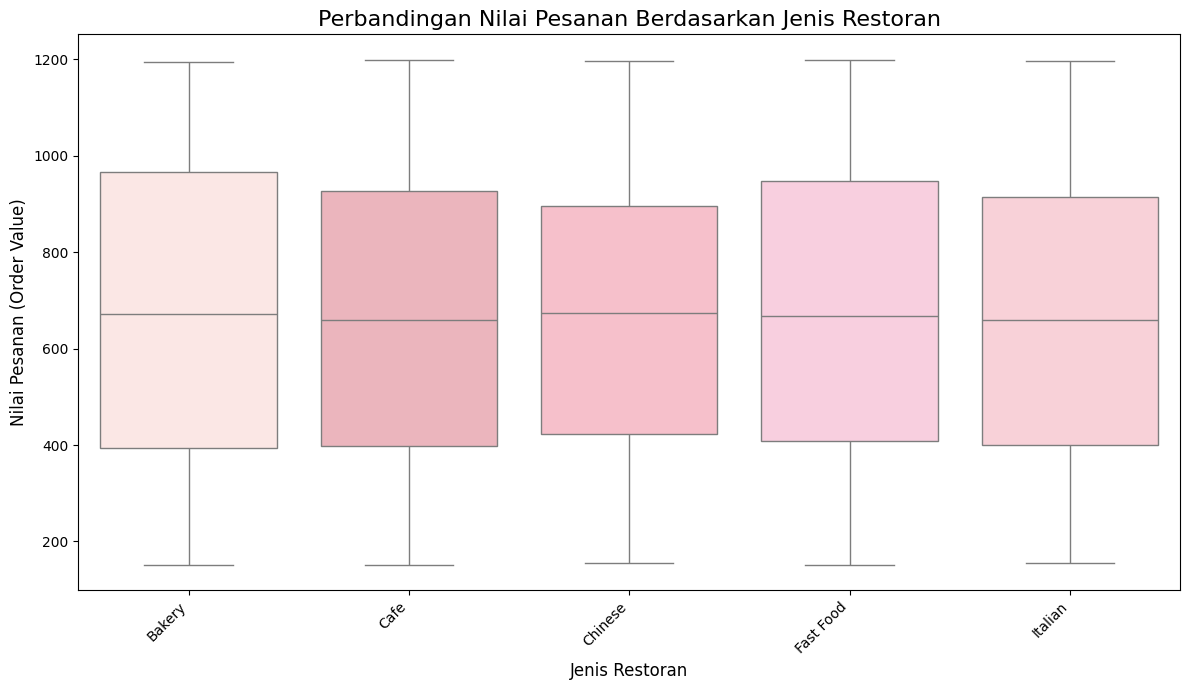

In [ ]:
VARIABEL1 = df['restaurant_type'].value_counts().head(5).index
VARIABEL2 = df[df['restaurant_type'].isin(VARIABEL1)]

plt.figure(figsize=(12, 7)) # Ukuran figure
sns.boxplot(x='restaurant_type', y='order_value', data=VARIABEL2, palette=['#FFE4E1','#FFCAD4','#F4ACB7','#FFB7C5','#FFC8DD'], order=VARIABEL1, hue='restaurant_type', legend=False)
plt.title('Perbandingan Nilai Pesanan Berdasarkan Jenis Restoran', fontsize=16) # Judul
plt.xlabel('Jenis Restoran', fontsize=12) # X Keterangan
plt.ylabel('Nilai Pesanan (Order Value)', fontsize=12) # Y Keterangan
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Berdasarkan visualisasi tersebut, terlihat bahwa tidak ada perbedaan signifikan pada nilai pesanan di antara kelima jenis restoran yang dibandingkan (Bakery, Cafe, Chinese, Fast Food, dan Italian). Garis tengah di dalam kotak (median) menunjukkan bahwa rata-rata pengeluaran pelanggan berada di level yang hampir serupa, yakni di kisaran 650 hingga 700. Selain itu, rentang sebaran datanya pun sangat mirip, di mana sebagian besar pesanan berada di angka 400 hingga 950 dengan batas tertinggi mencapai hampir 1.200. Hal ini mengindikasikan bahwa perilaku belanja konsumen cenderung mengeluarkan jumlah uang yang kurang lebih sama tanpa mempedulikan kategori restoran yang mereka pilih.

**Solusi**

solusinya adalah kita bisa menerapkan promo "Menu Rekomendasi" di setiap jenis restoran untuk mendorong pelanggan belanja sedikit lebih banyak agar melewati angka 950. Selain itu, kita bisa mencoba membuat program loyalitas gabungan (poin yang bisa dipakai di semua jenis restoran ini) karena pelanggan terbukti memiliki anggaran belanja yang sama di mana pun mereka makan.

##**Distribution**

Visualisasi data pada pilar utama distribution ini kita akan mencari tahu apakah kebanyakan pesanan bernilai kecil, sedang, atau besar. Juga mencari tau distribusi waktu pengiriman dengan tujuan mengetahui apakah rating kurir cenderung tinggi, sedang, atau rendah.

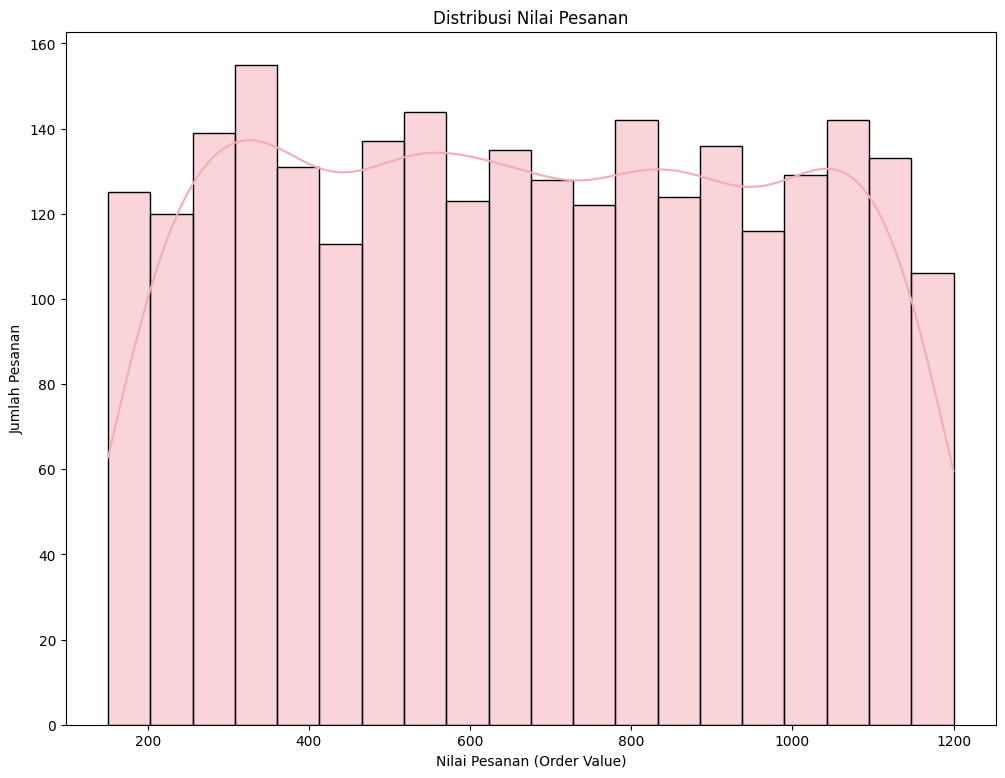

In [ ]:
plt.figure(figsize=(12, 9))
sns.histplot(df['order_value'], bins=20, kde=True, color='#F4ACB7')
plt.title('Distribusi Nilai Pesanan')
plt.xlabel('Nilai Pesanan (Order Value)')
plt.ylabel('Jumlah Pesanan')
plt.show()

Berdasarkan grafik tersebut, terlihat bahwa nilai pesanan memiliki distribusi yang sangat merata atau seragam di sepanjang rentang 150 hingga 1.200. Artinya, tidak ada satu kelompok harga tertentu yang mendominasi secara mencolok; pelanggan melakukan pemesanan dengan frekuensi yang hampir sama banyaknya, baik untuk nominal yang kecil maupun yang besar. Hal ini menunjukkan profil bisnis yang sangat seimbang, di mana daya tarik produk tersebar secara konsisten di berbagai segmen harga tanpa adanya ketergantungan pada satu kategori nilai transaksi saja.

**Solusi**

solusinya adalah dengan membuat promo paket hemat untuk menarik lebih banyak pesanan di angka kecil, atau memberikan gratis ongkir khusus untuk pesanan di atas 1.000 agar pelanggan semakin semangat belanja dalam jumlah banyak. Dengan cara ini, kita bisa mendorong kategori harga yang paling menguntungkan bagi bisnis tanpa kehilangan pelanggan di segmen lainnya.

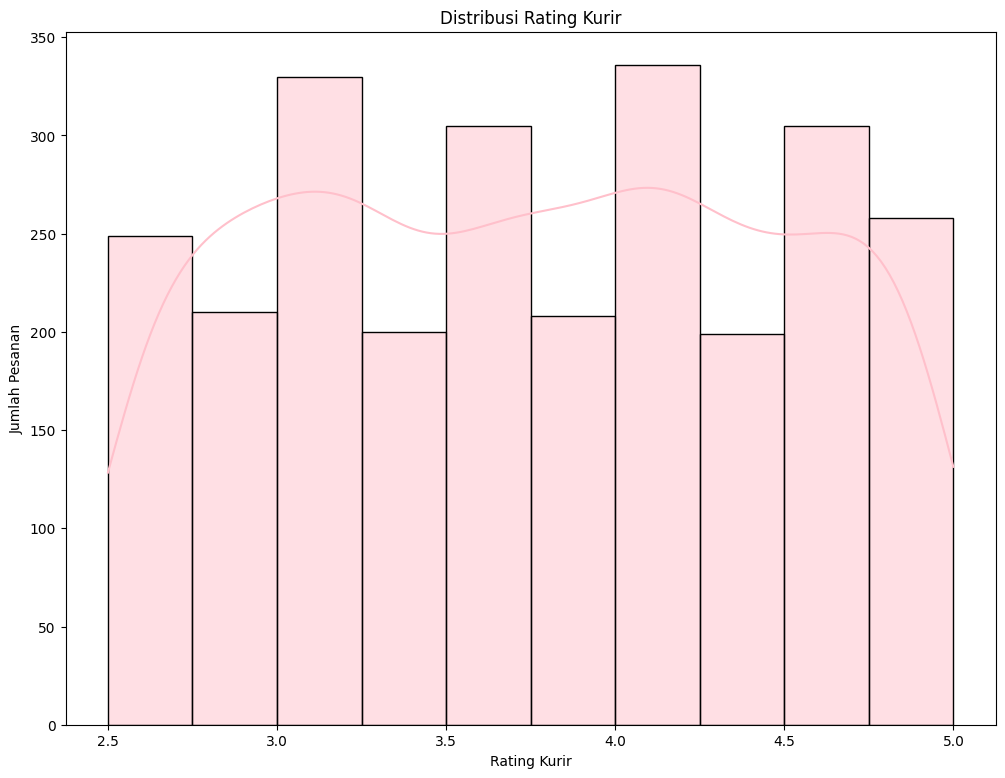

In [ ]:
plt.figure(figsize=(12, 9))
sns.histplot(df['delivery_partner_rating'], bins=10, kde=True, color='pink')
plt.title('Distribusi Rating Kurir')
plt.xlabel('Rating Kurir')
plt.ylabel('Jumlah Pesanan')
plt.show()

Visualisasi Distribusi Rating Kurir menunjukkan bahwa kualitas layanan pengiriman saat ini masih sangat bervariasi dan belum konsisten karena nilai yang diberikan pelanggan tersebar hampir merata di seluruh rentang. Alih-alih didominasi oleh nilai sempurna, grafik ini memiliki beberapa puncak di angka rating 3.0, 4.0, dan 4.5, yang berarti pengalaman pelanggan saat menerima pesanan sering kali "untung-untungan" atau berbeda-beda setiap kali memesan. Masih banyaknya pesanan yang mendapatkan rating rendah di kisaran 2.5 hingga 3.0 menjadi sinyal penting bagi bisnis untuk segera memperbaiki standar pelayanan kurir agar kepuasan pelanggan bisa lebih stabil di angka yang lebih tinggi.

**Solusi**

Melihat grafik rating kurir yang naik-turun ini, terlihat bahwa kualitas pengantaran masih belum stabil karena banyak pelanggan yang memberikan nilai rendah seperti 2.5 atau 3.0. Untuk memperbaikinya, solusinya adalah memberikan bonus atau hadiah kepada kurir yang konsisten mendapatkan bintang 5 agar mereka lebih semangat bekerja dengan baik. Selain itu, bagi kurir yang sering dapat rating rendah, sebaiknya diberikan pelatihan ulang cara membawa makanan agar tetap rapi dan bersikap lebih ramah kepada pelanggan. Terakhir, kita bisa membuat sistem laporan singkat di aplikasi supaya pelanggan bisa langsung memberitahu apa yang kurang, apakah makanannya terlambat atau kurirnya kurang sopan.

##**Composition**

Visualisasi data pada pilar utama composition ini kita akan mencari tahu proporsi pesanan Delivered, Cancelled, Delayed, proporsi customer age group, dan proporsi payment method. Dengan menggunakan visualisasi pie chart.

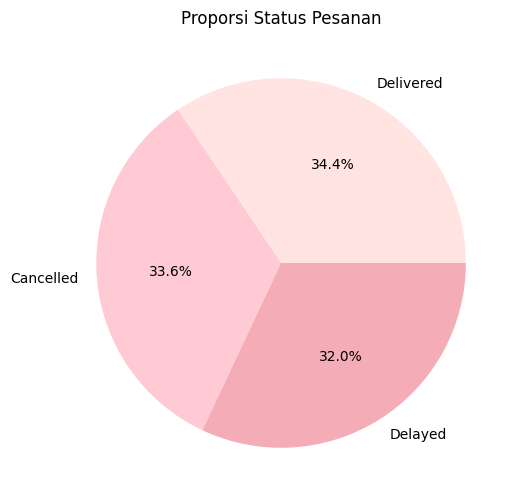

In [ ]:
plt.figure(figsize=(10, 6)) # ukuran
plt.pie(df['order_status'].value_counts(), labels=df['order_status'].value_counts().index, autopct='%1.1f%%', colors=['#FFE4E1', '#FFCAD4', '#F4ACB7']) # colors (warna)
plt.title('Proporsi Status Pesanan') # Judul
plt.show()

Berdasarkan visualisasi di atas, ketiga grafik ini menunjukkan adanya masalah serius pada operasional pengiriman, di mana hanya sekitar 34.4% pesanan yang berhasil sampai tepat waktu (Delivered), sementara sisanya mengalami keterlambatan (32%) atau pembatalan (33.6%). Masalah ini berdampak langsung pada kepuasan pelanggan, yang terlihat dari rating kurir yang sangat tidak stabil dan sering rendah di angka 2.5 hingga 3.0, meskipun minat beli pelanggan sebenarnya sangat besar dan merata di berbagai rentang harga.

**Solusi**

 Kita perlu segera menambah jumlah kurir atau mengoptimalkan rute pengiriman untuk menekan angka keterlambatan, serta memberikan pelatihan standar pelayanan bagi kurir agar rating tidak jomplang. Selain itu, berikanlah voucher diskon otomatis bagi pelanggan yang pesanannya terlambat atau dibatalkan sebagai permohonan maaf agar mereka tidak kapok untuk memesan kembali di masa depan.

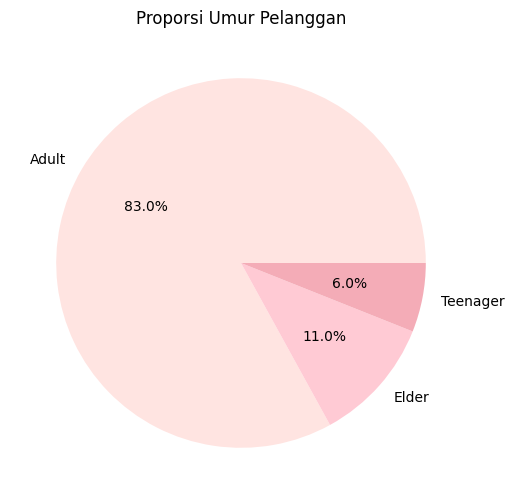

In [ ]:
plt.figure(figsize=(10, 6)) # ukuran
plt.pie(df['customer_age_group'].value_counts(), labels=df['customer_age_group'].value_counts().index, autopct='%1.1f%%', colors=['#FFE4E1', '#FFCAD4', '#F4ACB7']) # colors (warna)
plt.title('Proporsi Umur Pelanggan') # Judul
plt.show()

Berdasarkan visualisasi tersebut, terlihat bahwa mayoritas pelanggan  berasal dari kelompok Adult (Dewasa) dengan persentase mencapai 83%. Kelompok ini menunjukkan minat belanja yang sangat stabil dan merata, di mana jumlah pesanan tetap konsisten di seluruh rentang harga, mulai dari nominal kecil senilai 150 hingga pesanan besar mencapai 1.200. Karena tidak ada satu kelompok harga yang mendominasi, bisnis Anda memiliki profil konsumen yang sangat beragam dan tidak bergantung pada satu jenis nilai transaksi saja.

**Solusi**

Kita dapat fokus membuat program keanggotaan (loyalty program) yang dirancang khusus untuk kelompok dewasa guna menjaga konsistensi belanja mereka yang sudah sangat baik. Selain itu, karena distribusi pesanan sangat merata, Anda bisa menerapkan strategi bundling atau paket hemat pada rentang harga tertentu untuk mendorong pelanggan yang biasa memesan di angka kecil agar menaikkan nilai belanjanya ke angka yang lebih tinggi.

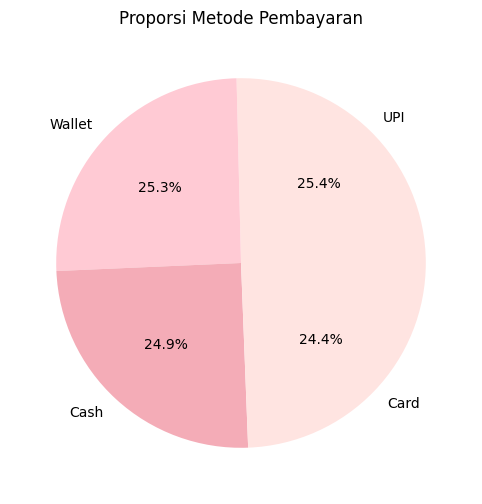

In [ ]:
plt.figure(figsize=(10, 6)) # ukuran
plt.pie(df['payment_method'].value_counts(), labels=df['payment_method'].value_counts().index, autopct='%1.1f%%', colors=['#FFE4E1', '#FFCAD4', '#F4ACB7']) # colors (warna)
plt.title('Proporsi Metode Pembayaran') # Judul
plt.show()

Berdasarkan visualisasi tersebut, penggunaan metode pembayaran di bisnis terlihat sangat seimbang dan merata, di mana pelanggan menggunakan UPI (25,4%), Wallet (25,3%), Cash (24,9%), dan Card (24,4%) dengan porsi yang hampir sama besar. Hal ini menunjukkan bahwa sistem pembayaran sudah sangat fleksibel dan berhasil memfasilitasi berbagai preferensi transaksi pelanggan tanpa ada satu metode pun yang mendominasi secara mencolok.

**Solusi**

Kita sebaiknya mempertahankan semua opsi pembayaran ini dan bisa mulai bekerja sama dengan penyedia layanan tertentu (seperti Bank atau E-wallet) untuk mengadakan promo cashback atau diskon khusus guna menarik lebih banyak transaksi di kategori nilai pesanan yang lebih tinggi. Selain itu, pastikan kestabilan jaringan pada sistem pembayaran digital tetap terjaga agar kenyamanan pelanggan yang sudah merata ini tidak terganggu oleh kendala teknis.

##**Relationship**


Visualisasi data pada pilar utama relationship ini kita akan mencari tahu hubungan numerik antar variabel sekaligus.

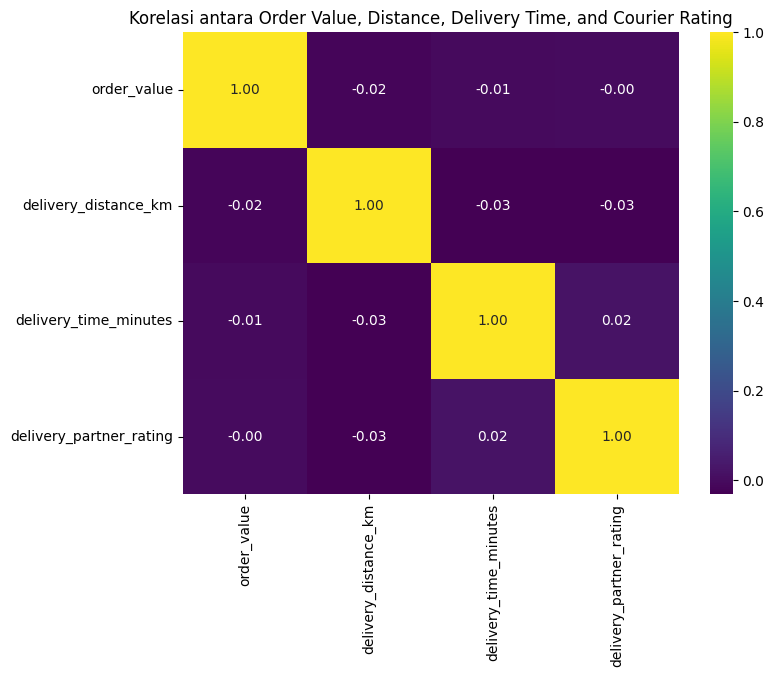

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(data=df[['order_value', 'delivery_distance_km', 'delivery_time_minutes', 'delivery_partner_rating']].corr(),
            annot=True,
            cmap='viridis',
            fmt='.2f')
plt.title('Korelasi antara Order Value, Distance, Delivery Time, and Courier Rating')
plt.show()

Berdasarkan visualisasi tersebut, penggunaan metode pembayaran terlihat sangat seimbang dan merata, di mana pelanggan menggunakan UPI (25,4%), Wallet (25,3%), Cash (24,9%), dan Card (24,4%) dengan porsi yang hampir sama besar. Hal ini menunjukkan bahwa sistem transaksi kita sudah sangat fleksibel dan berhasil mengakomodasi berbagai preferensi pembayaran pelanggan tanpa ada satu metode pun yang mendominasi secara mencolok.

**Solusi**

Kita sebaiknya mempertahankan semua opsi pembayaran yang ada dan bisa mulai bekerja sama dengan penyedia layanan tertentu (seperti Bank atau dompet digital) untuk mengadakan promo cashback atau diskon khusus guna mendorong peningkatan nilai transaksi pada metode pembayaran yang paling efisien secara biaya bagi operasional kita. Selain itu, pastikan kestabilan integrasi sistem pada setiap gerbang pembayaran tetap terjaga agar kenyamanan pelanggan yang sudah merata ini tidak terganggu oleh kendala teknis saat proses pembayaran.

#**Menyimpan File Dataset**

In [ ]:
output_path = "/content/drive/MyDrive/AVD/Checkpoint_2_AVD.xlsx"

df.to_excel(output_path, index=False)
print("File berhasil tersimpan")

File berhasil tersimpan
